# Исследование ёмкости embedding векторов, когда кол-во фичей >> размерности эмбеддинга (overcomplete базис)

In [1]:
import os, sys

import math
from collections import defaultdict, namedtuple, Counter
import json
import re
import pprint
from enum import Flag, StrEnum, auto # @launchit.collect

from tqdm.notebook import tqdm
import numpy as np
import cupy as cp
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]

sys.path.append(os.path.join(project_root_path, 'lib'))
from utils import *
from logging_utils import *

# Setup

In [2]:
LOG = Logging.get()
RNG = np.random.default_rng()
ArrayUtils.init()
xp = ArrayUtils.xp

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    self_fname='',
    self_name='',
    subproject_name='',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/experiment/hdc',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'self_fname': '/home/misha/dev/mine/neurovision/experiment/hdc/embedding.ipynb',
 'self_name': 'embedding',
 'subproject_name': 'hdc',
 'is_cuda': True,
 'cuda_device': 'cuda',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



## Embedding Size, ES=768

In [5]:
EMBEDDING_SIZE = 768

## Feature Bank Size, FBS

FBS - сколько всего фичей знает система. Банк знаний

## Features Count, FC

FC - сколько фичей (их значений) мы хотим записать в один HDV. Чем больше, тем тяжелее. Если FBS <= EMBEDDING_SIZE, то безошибочно можн сохранить FBS фичей. Если FBS >> EMBEDDING_SIZE, то уже неизбежно будут ошибки, т.к. фичи будут хоть немного, но коррелированы, и сохранение нескольких фичей в один вектор будет приводить к фантомным значениям фичей (которые мы даже и не хотели сохранять).

## Real-valued features

### ES/FBS/FC=768/100000/100, оптимизация

In [13]:
FEATURES_BANK_SIZE = 100_000
FEATURES_COUNT = 100

Сначала интересно посмотреть, что будет если у нас полностью равноправные фичи, без какой-либо кластеризации (нет подпространств). Можно ли снизить ошибку кодирования/декодирования чисто за счёт тонкой подстройки?

In [14]:
features = RNG.uniform(-1, +1, size=(FEATURES_BANK_SIZE, EMBEDDING_SIZE)).astype('float32')
features = (features.T / np.linalg.norm(features, axis=1)).T
features = torch.tensor(features, device=CONFIG.cuda_device)

In [15]:
# Manually build histogram because building full cos_sims matrix requires too much memory (doesn't fit into GPU)
def get_feature_cos_sims_histogram(features, method=1, buckets_count=10):
    min_cos_sim, max_cos_sim = 0, 0
    
    for features_batch in tqdm(DataLoader(features, batch_size=1000), leave=False):
        cos_sims = features_batch @ features.T
        min_cos_sim = min(min_cos_sim, cos_sims.min().item())
        max_cos_sim = max(max_cos_sim, cos_sims.max().item())
    
    if method == 1:
        buckets = Counter()
        
        for features_batch in tqdm(DataLoader(features, batch_size=1000), leave=False):
            cos_sims = (features_batch @ features.T).ravel()
            # map each cos_sim to 0..1 (where 0 stands for min_cos_sim 1 - max_cos_sim)
            cos_sims = (cos_sims - min_cos_sim) / (max_cos_sim - min_cos_sim)
            # map each cos_sim to bucket index
            bucket_indices = (cos_sims * buckets_count).to(int)
            buckets.update(dict(zip(*np.unique_counts(bucket_indices.cpu().numpy()))))

        step = (max_cos_sim - min_cos_sim) / buckets_count
        bucket_centers = list(map(lambda i: min_cos_sim + step * i + step / 2, np.arange(buckets_count)))
        buckets = list(map(lambda i: buckets.get(i, 0), np.arange(buckets_count)))
        return buckets, bucket_centers
    elif method == 2:
        # Equivalent but a little bit slower code
        buckets = None
        
        for features_batch in tqdm(DataLoader(features, batch_size=1000), leave=False):
            cos_sims = (features_batch @ features.T).ravel()
            h = np.histogram(cos_sims.cpu().numpy(), bins=buckets_count, range=(min_cos_sim, max_cos_sim))
        
            if buckets is None:
                buckets = h
            else:
                assert np.all(buckets[1] == h[1])
                buckets[0][:] = buckets[0] + h[0]

        bucket_centers = list(map(lambda x: (x[0] + x[1]) / 2, zip(h[1][0:], h[1][1:])))
        return buckets, bucket_centers

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

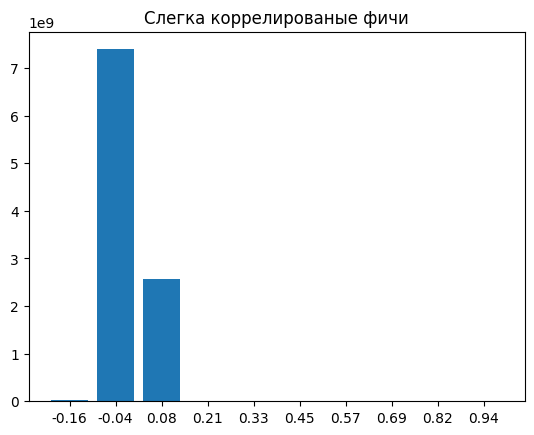

In [16]:
buckets, bucket_centers = get_feature_cos_sims_histogram(features)
labels = list(map(lambda i: f'{i:.2f}', bucket_centers))
plt.title('Слегка коррелированые фичи')
plt.bar(labels, buckets);

In [17]:
# decorrelate feature axes by gradient descent optimization procedure
features.requires_grad_(True)
optimizer = torch.optim.Adam([features], lr=0.00005)
batch_size = 100
epochs_count = 10_000
losses_track = []

for epoch in tqdm(range(epochs_count + 1)):
    optimizer.zero_grad()
    
    batch = np.zeros((batch_size, len(features)), dtype='float32')

    for i in range(len(batch)):
        feature_inds = RNG.choice(len(features), FEATURES_COUNT, replace=False)
        # craft a disentagled representation of features (1 feature = 1 slot)
        batch[i,feature_inds] = RNG.uniform(0, 1, size=FEATURES_COUNT).astype('float32')

    batch = torch.tensor(batch, device=CONFIG.cuda_device)
    # encode -> make embedding for each sample in batch: scale each feature by corresponding value, sum all features (disentagled to distributed representation)
    # mnemonics: feature (axes) are in columns, samples are in columns. Think model: each basis to vector multiplication
    embeddings = (features.T @ batch.T).T
    # decode -> extract feature values from embedding
    # mnemonics: embedding in rows, features in columns
    batch_hat = F.relu(embeddings @ features.T)
    loss = F.mse_loss(batch_hat, batch)

    if epoch > 0:
        loss.backward()
        optimizer.step()

    losses_track.append(loss.item())

    # normalize feature axes (bases)
    with torch.no_grad():
        features[:] = (features.T / torch.linalg.vector_norm(features, dim=1)).T
    
    if (epoch % 500) == 0:
        print(f'{epoch=}, {loss.item()=}')

  0%|          | 0/10001 [00:00<?, ?it/s]

epoch=0, loss.item()=0.021690409630537033
epoch=500, loss.item()=0.021768994629383087
epoch=1000, loss.item()=0.021617287769913673
epoch=1500, loss.item()=0.021671688184142113
epoch=2000, loss.item()=0.021536819636821747
epoch=2500, loss.item()=0.0218130461871624
epoch=3000, loss.item()=0.021863603964447975
epoch=3500, loss.item()=0.02175668068230152
epoch=4000, loss.item()=0.021525556221604347
epoch=4500, loss.item()=0.02142561413347721
epoch=5000, loss.item()=0.02151627466082573
epoch=5500, loss.item()=0.02128600887954235
epoch=6000, loss.item()=0.02158372476696968
epoch=6500, loss.item()=0.021670419722795486
epoch=7000, loss.item()=0.021625908091664314
epoch=7500, loss.item()=0.02137351781129837
epoch=8000, loss.item()=0.021713167428970337
epoch=8500, loss.item()=0.02134094387292862
epoch=9000, loss.item()=0.021667934954166412
epoch=9500, loss.item()=0.021665044128894806
epoch=10000, loss.item()=0.021585160866379738


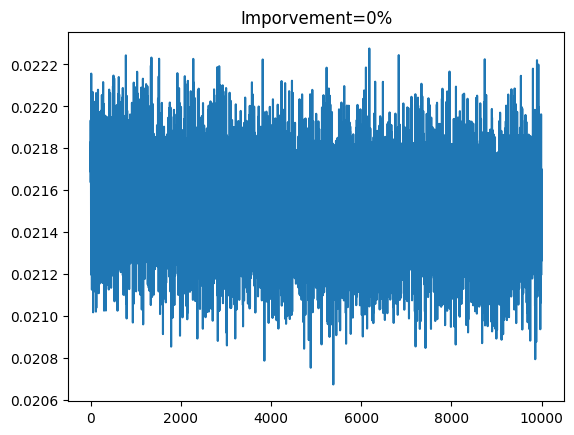

In [18]:
plt.title(f'Imporvement={100 * (1 - losses_track[-1] / losses_track[0]):.0f}%')
plt.plot(range(len(losses_track)), losses_track);

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

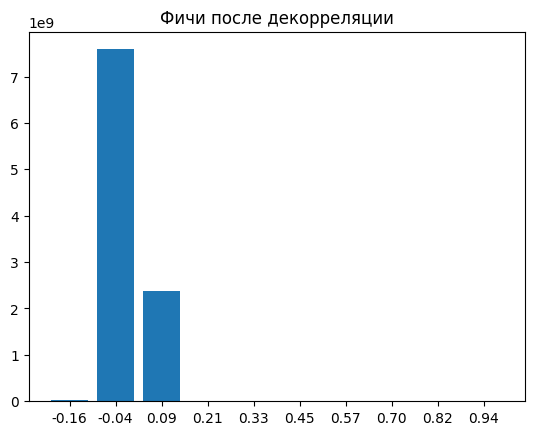

In [19]:
buckets, bucket_centers = get_feature_cos_sims_histogram(features)
labels = list(map(lambda i: f'{i:.2f}', bucket_centers))
plt.title('Фичи после декорреляции')
plt.bar(labels, buckets);

**ВЫВОДЫ**

Видно, что декорреляция "в лоб", когда FBS>>ES, ничего не даёт. В одном месте улучшаем, тут же ломается в другом месте, поэтому и видны "метания".

### ES/FBS/FC=768/100000/100+bias, оптимизация

In [ ]:
FEATURES_BANK_SIZE = 100_000
FEATURES_COUNT = 100

In [ ]:
features = RNG.uniform(-1, +1, size=(FEATURES_BANK_SIZE, EMBEDDING_SIZE)).astype('float32')
features = (features.T / np.linalg.norm(features, axis=1)).T
features = torch.tensor(features, device=CONFIG.cuda_device)

In [ ]:
# decorrelate feature axes by gradient descent optimization procedure
features.requires_grad_(True)
biases = torch.zeros(len(features), requires_grad=True, device=CONFIG.cuda_device)
optimizer = torch.optim.Adam([features, biases], lr=0.00005)
batch_size = 100
epochs_count = 10_000
losses_track = []

for epoch in tqdm(range(epochs_count + 1)):
    optimizer.zero_grad()
    
    batch = np.zeros((batch_size, len(features)), dtype='float32')

    for i in range(len(batch)):
        feature_inds = RNG.choice(len(features), FEATURES_COUNT, replace=False)
        sample_biases = biases[feature_inds]
        assert len(sample_biases) == FEATURES_COUNT
        # craft a disentagled representation of features (1 feature = 1 slot)
        batch[i,feature_inds] = RNG.uniform(0, 1, size=FEATURES_COUNT).astype('float32') + sample_biases

    batch = torch.tensor(batch, device=CONFIG.cuda_device)
    # encode -> make embedding for each sample in batch: scale each feature by corresponding value, sum all features (disentagled to distributed representation)
    # mnemonics: feature (axes) are in columns, samples are in columns. Think model: each basis to vector multiplication
    embeddings = (features.T @ batch.T).T
    # decode -> extract feature values from embedding
    # mnemonics: embedding in rows, features in columns
    batch_hat = F.relu(embeddings @ features.T)
    loss = F.mse_loss(batch_hat, batch)

    if epoch > 0:
        loss.backward()
        optimizer.step()

    losses_track.append(loss.item())

    # normalize feature axes (bases)
    with torch.no_grad():
        features[:] = (features.T / torch.linalg.vector_norm(features, dim=1)).T
    
    if (epoch % 500) == 0:
        print(f'{epoch=}, {loss.item()=}')

In [ ]:
assert False

In [205]:
# features_count_list = 1 + np.arange(100)
features_count_list = [10]
diff_metrics = defaultdict(list)
# bias is used to artificially raise up feature values during encoding and lower down during decoding
# without bias it won't be possible to distinguish between noise and low valued feature. E.g. 0.05 - is this a feature value or just noise?
bias = 1

for features_count in tqdm(features_count_list):
    feature_inds = RNG.choice(len(features), features_count, replace=False)
    feature_values = np.zeros(len(features))
    # craft a disentagled representation of features (1 feature = 1 slot)
    feature_values[feature_inds] = RNG.uniform(0, 1, size=(features_count)) + bias 
    # feature_values[feature_inds] = RNG.uniform(1, 2, size=(features_count))
    # encode -> make embedding: scale each feature by corresponding value, sum all features (disentagled -> distributed representation)
    embedding = ((features.T * feature_values).T).sum(axis=0) 
    # decode -> extract feature values from embedding
    feature_values_hat = F.relu(torch.tensor(features @ embedding) - bias).numpy()
    # feature_values_hat = (features @ embedding) - bias
    diff = feature_values - feature_values_hat
    abs_diff = np.abs(diff)
    diff_metrics['absmin'].append(abs_diff.min())
    diff_metrics['absmax'].append(abs_diff.max())
    diff_metrics['absmean'].append(abs_diff.mean())
    diff_metrics['mse_loss'].append((diff ** 2).sum() / len(feature_values))
    diff_metrics['l1_loss'].append(abs_diff.sum() / len(feature_values))

  0%|          | 0/1 [00:00<?, ?it/s]

In [40]:
# features_count_list = 1 + np.arange(100)
# # features_count_list = [50]
# diff_metrics = defaultdict(list)

# for features_count in features_count_list:
#     features = RNG.uniform(-1, +1, size=(features_count, EMBEDDING_SIZE))
#     features = (features.T / np.linalg.norm(features, axis=1)).T
#     # feature_values = RNG.uniform(size=(features_count))
#     feature_values = np.ones(features_count)
#     # encode -> make embedding (scale each feature by corresponding value, sum all features)
#     embedding = ((features.T * feature_values).T).sum(axis=0) 
#     # decode -> extract feature values from embedding
#     feature_values_hat = F.relu(torch.tensor(features @ embedding)).numpy()
#     diff = feature_values - feature_values_hat
#     diff_metrics['absmin'].append(np.abs(diff).min())
#     diff_metrics['absmax'].append(np.abs(diff).max())
#     diff_metrics['mse_loss'].append((diff ** 2).sum() / features_count)
#     diff_metrics['l1_loss'].append(np.abs(diff).sum() / features_count)

In [206]:
i = int(feature_inds.min())
i

9091

In [207]:
feature_values[i] - bias

np.float64(0.9644340008122136)

In [211]:
(features @ embedding)[i-1:i+2], F.relu(torch.tensor((features @ embedding)[i-1:i+2] - bias))

(array([0.20397862, 2.08316732, 0.05819072]),
 tensor([0.0000, 1.0832, 0.0000], dtype=torch.float64))

In [172]:
# ((features.T * (feature_values)).T)[2655]

In [173]:
# fig, (ax1, ax2) = plt.subplots(2, 1)
# fig.set_figwidth(18)
# fig.set_figheight(6)

# for key in ('mse_loss', 'l1_loss'):
#     values = diff_metrics[key]
#     ax1.plot(features_count_list, values, label=key)
#     ax1.grid(True)
#     ax1.legend();

# for key in ('absmin', 'absmax', 'absmean'):
#     values = diff_metrics[key]
#     ax2.plot(features_count_list, values, label=key)
#     ax2.grid(True)
#     ax2.legend();

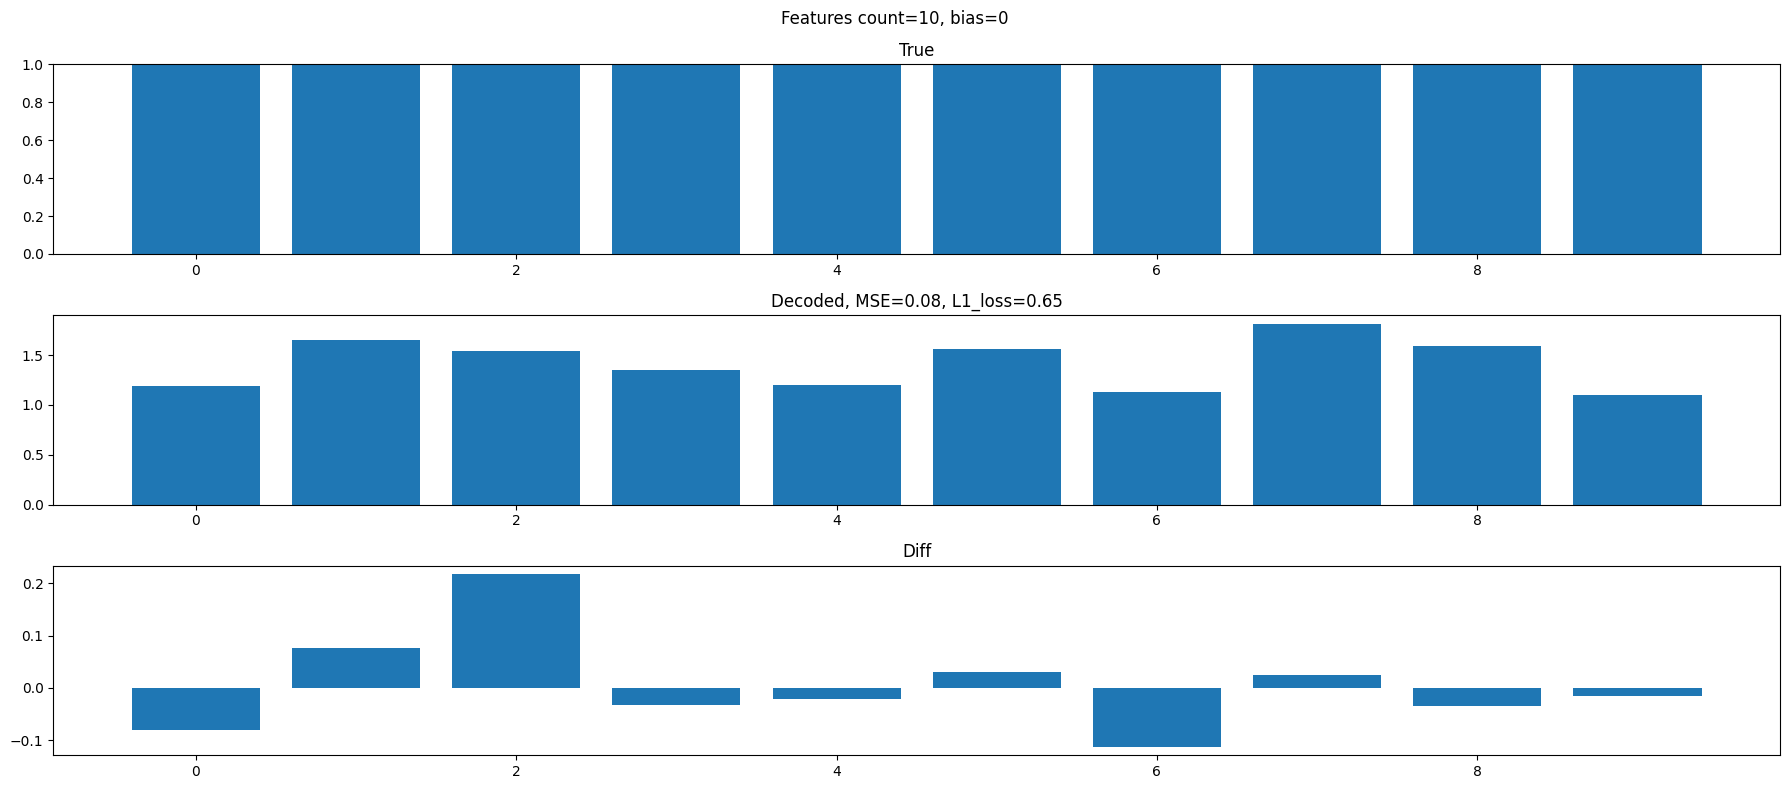

In [204]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1)
fig.set_figwidth(18)
fig.set_figheight(8)
fig.suptitle(f'Features count={int(features_count)}, {bias=}')
ax1.set_title('True')
true_feature_values = feature_values[feature_inds] - bias
decoded_feature_values = feature_values_hat[feature_inds]
ax1.bar(np.arange(len(true_feature_values)), true_feature_values, label='true')
ax1.set_ylim(0, 1)
ax2.set_title(f'Decoded, MSE={F.mse_loss(torch.tensor(decoded_feature_values), torch.tensor(true_feature_values), reduction='sum'):.2f}, ' + 
              f'L1_loss={F.l1_loss(torch.tensor(decoded_feature_values), torch.tensor(true_feature_values), reduction='sum'):.2f}')
ax2.bar(np.arange(len(true_feature_values)), decoded_feature_values, label='decoded')
# ax2.set_ylim(0, 1)
ax3.set_title('Diff')
ax3.bar(np.arange(len(true_feature_values)), true_feature_values - decoded_feature_values)
# ax3.set_ylim(-1, 1);
fig.tight_layout();

Зачем HDC?

Если без HDC, то мы остаёмся с disentangled features. Следовательно:
1) Для миллиона фичей, потребовался бы миллион разрядов.
2) 99% разрядов скорее всего были бы забиты 0 - огромный перерасход.
3) т.к. фичи копятся на протяжении жизни, то мы бы платили огромный налог на то, что половина емкости не используется
4) Непонятно, как добавить новую фичу. Увеличивать кол-во разрядов?

Sparsed в том смысле, что не сразу все фичи мы используем, а только небольшую их часть. Например, 80 фич из 1 млн.

# Справочно

## Мысли и соображения

Возьмём disentangled representation, когда одна фича - один разряд. В этом случае, сколько разрядов, столько и уникальных фичей можно безупречнно закодировать и декодировать в векторе. 3D -> 3 фичи, 300D -> 300 фичей.

Теперь возьмем distributed representation, где фичи - это направления, которые не на 100% орогональны (т.е. имеется некоторая коррелированность). С одной стороны это плохо, с другой - хорошо, т.к. кол-во фичей, которое можно положить в вектор, увеличивается очень сильно (на порядки). Т.е. закодировать можно много информации. Другой вопрос - а что с раскодировкой, сколько можно прочитать информации без её зашумления?

Зачем HDC?

Если без HDC, то мы остаёмся с disentangled features. Следовательно:
1) Для миллиона фичей, потребовался бы миллион разрядов.
2) 99% разрядов скорее всего были бы забиты 0 - огромный перерасход.
3) т.к. фичи копятся на протяжении жизни, то мы бы платили огромный налог на то, что половина емкости не используется
4) Непонятно, как добавить новую фичу. Увеличивать кол-во разрядов?

Sparsed в том смысле, что не сразу все фичи мы используем, а только небольшую их часть. Например, 80 фич из 1 млн.

<img src="./img/embedding-1.jpg" >

Когда банк фичей меньше размерности встраивания (FBS < ES), то проблем с описанием вектора нет, т.к. каждую фичу можно совершенно закодировать и раскодировать. См. выше. Однако, когда кол-во фичей в банке много больше размерности встраивания (FBS >> ES), то возникает проблема - как хранить, как упаковывать, как кодировать/декодировать фичи в вектор?

**Вариант 1**

Каждую фичу, значение которой хотим зафиксировать, представить в виде пары: `(индекс фичи, значение)`. Тогда для ES=768, можно совершенно закодировать 768/2=384 фичи.

С одной стороны круто, с другой - мы уходим от линейной алгебры с её возможностью оперирования векторами в сторону этакого квадратно-гнездового кодирования. Чтобы сравнить векторы, нужно будет их линейно сканировать, либо держать в упорядоченном виде. Усложняется добавление/удаление элементов. Думаю, что главная причина, почему это в мозгу не используется в том, что такое кодирование биологически более трудно осуществимо, т.к. требует что-то типа CPU.

**Вариант 2**

Остаться в линейной алгебре. Но тогда возникает проблема, описанная выше - фичи-направления (коих стало ещё больше) слабокоррелированы. Поэтому при упаковке нескольких значений фичей в один вектор будет а) искажаться значения закодированных фичей б) могут появляться фантомные фичи (False positive), т.е. те которые мы не кодировали, но которые из-за коррелированности осей сами собой образовались.

Когда FBS<ES, это проблему легко решить путём декоррелирования фичей-направлений: хоть через точное аналитическое решение (QR), хоть через оптимизация. Но когда FBS>>ES полностью декоррелировать не получится. Следовательно, нужны ещё какие-то другие механизмы для обеспечения помехоустойчивости. Возможно, что сама природа сигналов поможет этому, т.к. фичи (направления) будут кластеризоваться. То есть например, будет подпространство из 100-200 фичей, описывающих человека, потом, например, 50 фичей, описывающих напитки и т.д. И эти подпространства будут состоять из декоррелированных фичей, но между подпространствами декорреляция и не важна. Типа логика такая, что если в естественной среде эти сущности/сигналы не перескаются, то и требование по ортогональности можно ослабить, т.к. отследить фантомную фичу можно будет просто по тому, к какому кластеру относятся данные. Т.е. если у нас активировались фича #1 и #100, но также активны ещё 20 фичей из кластера, к которому принадлежит #1, и лишь 2 фичи из кластера, к которому принадлежит #100, то можно смело сказать, что #100 - это фантомная фича, и таким образом подавить вообще весь соответствующий кластер (не думать про него)

## Размер встраивания для GPT

| Model | Embedding Size (Dimensions) |
|---|---|
| GPT-1 | 768 |
| GPT-2 | 1,600 (for the 1.5B model) |
| GPT-3 | 12,288 |
| GPT-4 | ~16,000 (Estimated) |
| GPT-5 | Not officially released |


## Кол-во слоёв GPT

| Model [2, 3, 4, 5, 6, 7, 8, 9] | Layers (Transformer Blocks) | Parameters (Largest Version) |
|---|---|---|
| GPT-1 | 12 | 117 Million |
| GPT-2 | 48 | 1.5 Billion |
| GPT-3 | 96 | 175 Billion |
| GPT-4 | ~120–128* | 1.7–1.8 Trillion (Estimated) |
| GPT-5 | 48* | Unknown (Projected MoE architecture) |


# Binary-values features

In [242]:
# features_count_list = 1 + np.arange(100)
# diff_metrics = defaultdict(list)
# threshold = 0.6 # the lower value is, the more false positives we get, can be reforumlated in a form of bias

# for features_count in tqdm(features_count_list):
#     feature_inds = RNG.choice(len(features), features_count)
#     feature_values = np.zeros(len(features))
#     # craft a disentagled representation of features (1 feature = 1 slot)
#     feature_values[feature_inds] = 1
#     # encode -> make embedding: scale each feature by corresponding value, sum all features (disentagled -> distributed representation)
#     embedding = ((features.T * feature_values).T).sum(axis=0) 
#     # decode -> extract feature values from embedding
#     dot_prod = (features @ embedding) 
#     feature_values_hat = np.where(dot_prod > threshold, 1, 0)
#     diff = feature_values - feature_values_hat
#     abs_diff = np.abs(diff)
#     diff_metrics['abs_min'].append(abs_diff.min())
#     diff_metrics['abs_max'].append(abs_diff.max())
#     diff_metrics['abs_mean'].append(abs_diff.mean())
#     diff_metrics['l1_loss'].append(abs_diff.sum() / len(feature_values)) # matches with MSE loss since abs_diff is one of {0,1}

  0%|          | 0/100 [00:00<?, ?it/s]

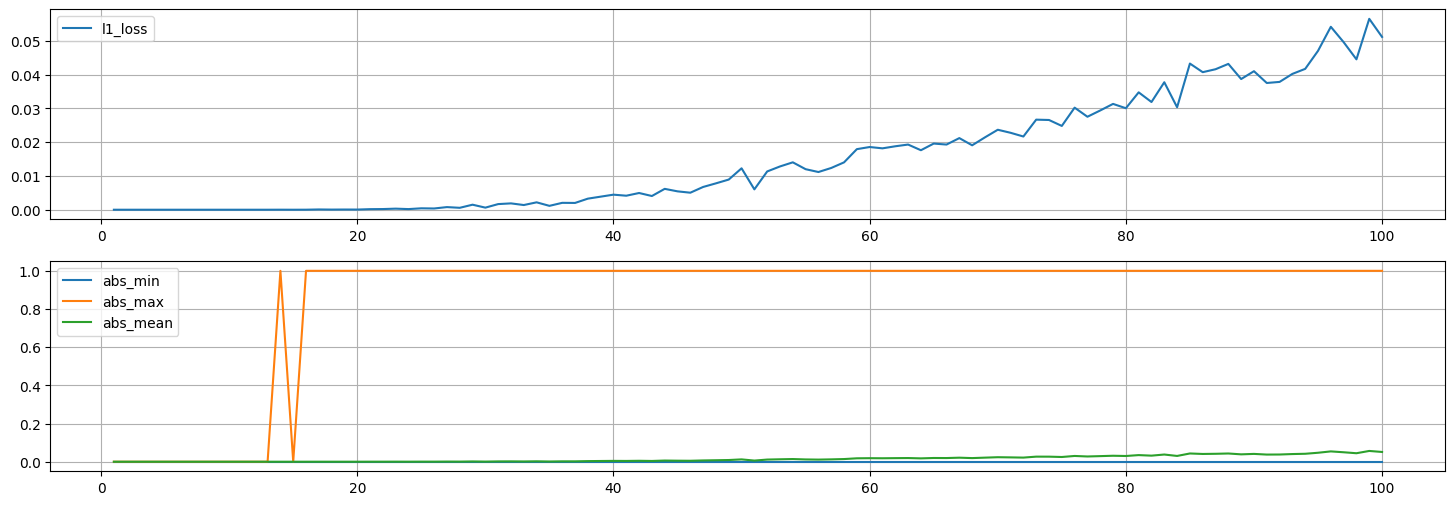

In [243]:
# fig, (ax1, ax2) = plt.subplots(2, 1)
# fig.set_figwidth(18)
# fig.set_figheight(6)

# for key in ('l1_loss', ):
#     values = diff_metrics[key]
#     ax1.plot(features_count_list, values, label=key)
#     ax1.grid(True)
#     ax1.legend();

# for key in ('abs_min', 'abs_max', 'abs_mean'):
#     values = diff_metrics[key]
#     ax2.plot(features_count_list, values, label=key)
#     ax2.grid(True)
#     ax2.legend();

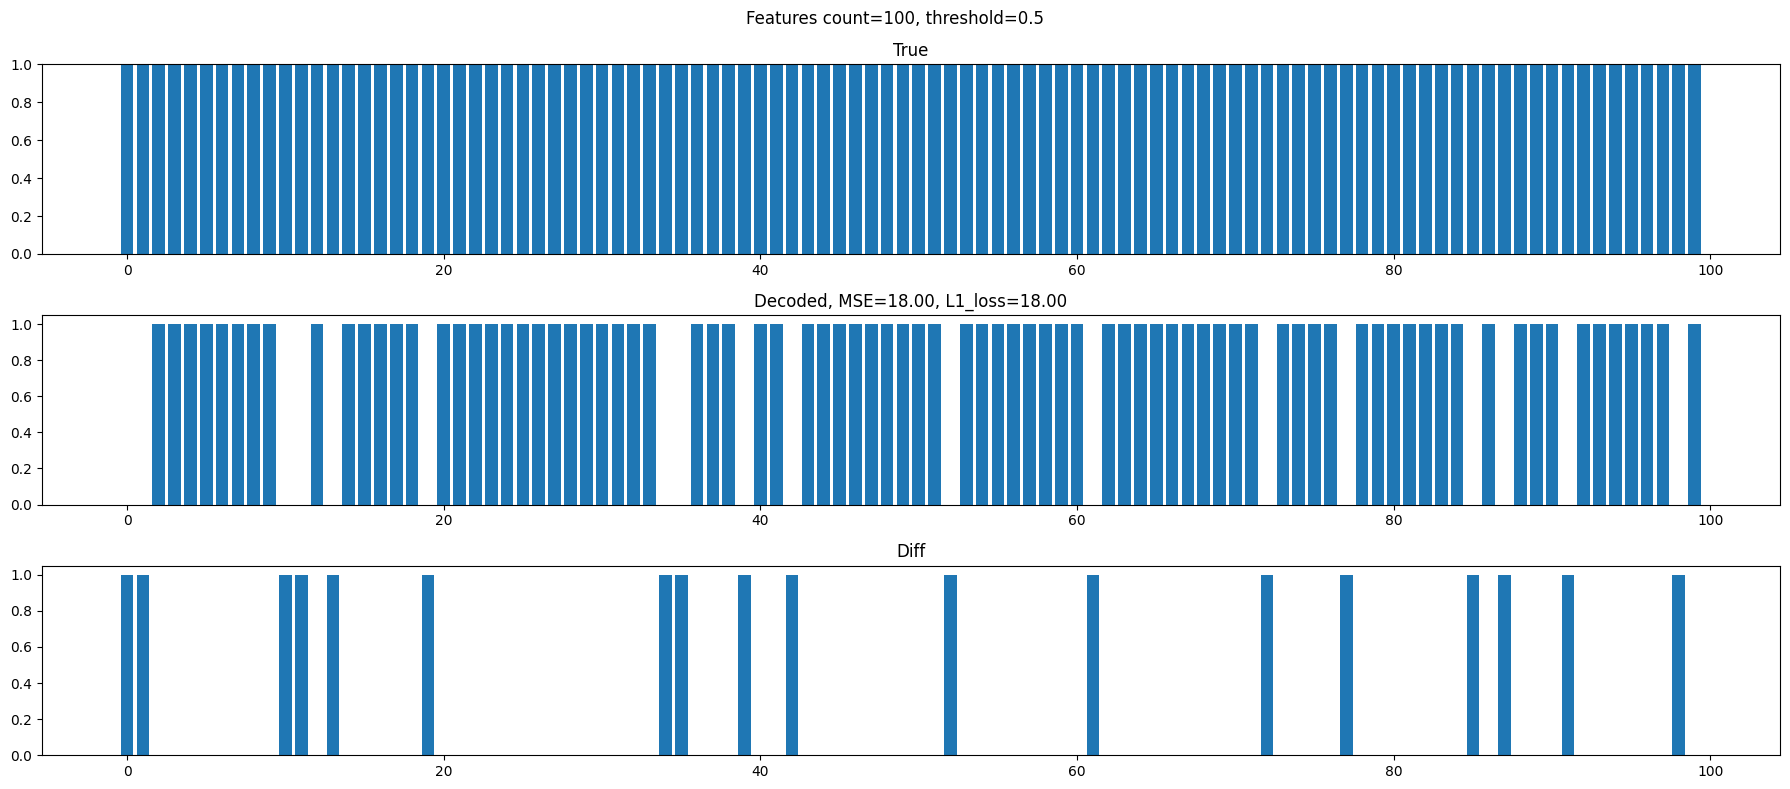

In [241]:
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1)
# fig.set_figwidth(18)
# fig.set_figheight(8)
# fig.suptitle(f'Features count={int(features_count)}, {threshold=}')
# ax1.set_title('True')
# true_feature_values = feature_values[feature_inds]
# decoded_feature_values = feature_values_hat[feature_inds]
# ax1.bar(np.arange(len(true_feature_values)), true_feature_values, label='true')
# ax1.set_ylim(0, 1)
# ax2.set_title(f'Decoded, MSE={F.mse_loss(torch.tensor(decoded_feature_values), torch.tensor(true_feature_values), reduction='sum'):.2f}, ' + 
#               f'L1_loss={F.l1_loss(torch.tensor(decoded_feature_values), torch.tensor(true_feature_values), reduction='sum'):.2f}')
# ax2.bar(np.arange(len(true_feature_values)), decoded_feature_values, label='decoded')
# # ax2.set_ylim(0, 1)
# ax3.set_title('Diff')
# ax3.bar(np.arange(len(true_feature_values)), true_feature_values - decoded_feature_values)
# # ax3.set_ylim(-1, 1);
# fig.tight_layout();